In [25]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [26]:
import pandas as pd
import numpy as np

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Pandas: 3.0.5
NumPy: 2.4.6


In [27]:
import pandas as pd 

df = pd.read_csv("../Data/News.csv")

df.head()


,headline,category,authors,short_description
0,There Were 2 Mass Shootings In Texas Last Wee...,CRIME,Melissa Jeltsen,She left her husband. He killed their childre...
1,Will Smith Joins Diplo And Nicky Jam For The ...,ENTERTAINMENT,Andy McDonald,Of course it has a song.
2,Hugh Grant Marries For The First Time At Age ...,ENTERTAINMENT,Ron Dicker,The actor and his longtime girlfriend Anna Eb...
3,Jim Carrey Blasts 'Castrato' Adam Schiff And ...,ENTERTAINMENT,Ron Dicker,The actor gives Dems an ass-kicking for not f...
4,Julianna Margulies Uses Donald Trump Poop Bag...,ENTERTAINMENT,Ron Dicker,The Dietland actress said using the bags is a...


In [28]:
print("Shape",df.shape)

Shape (200853, 4)


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200853 entries, 0 to 200852
Data columns (total 4 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   headline           200853 non-null  str  
 1   category           200853 non-null  str  
 2   authors            200851 non-null  str  
 3   short_description  200853 non-null  str  
dtypes: str(4)
memory usage: 46.6 MB


In [30]:
df.columns.to_list()

['headline', 'category', 'authors', 'short_description']

In [31]:
# Finding missing values in the dataset
df.isnull().sum()

headline             0
category             0
authors              2
short_description    0
dtype: int64

In [32]:
df.dtypes

headline             str
category             str
authors              str
short_description    str
dtype: object

In [33]:
# Lets perform EdA on category column
df['category'].value_counts()

category
POLITICS            32739
WELLNESS            17827
ENTERTAINMENT       16058
TRAVEL               9887
STYLE & BEAUTY       9649
PARENTING            8677
HEALTHY LIVING       6694
QUEER VOICES         6314
FOOD & DRINK         6226
BUSINESS             5937
COMEDY               5175
SPORTS               4884
BLACK VOICES         4528
HOME & LIVING        4195
PARENTS              3955
THE WORLDPOST        3664
WEDDINGS             3651
WOMEN                3490
IMPACT               3459
DIVORCE              3426
CRIME                3405
MEDIA                2815
WEIRD NEWS           2670
GREEN                2622
WORLDPOST            2579
RELIGION             2556
STYLE                2254
SCIENCE              2178
WORLD NEWS           2177
TASTE                2096
TECH                 2082
MONEY                1707
ARTS                 1509
FIFTY                1401
GOOD NEWS            1398
ARTS & CULTURE       1339
ENVIRONMENT          1323
COLLEGE              1144
LAT

##### Insights: There is imbalance in category column

In [34]:
print("No. of unique categories", df['category'].nunique())

print("\n Most common categories", df['category'].value_counts().head(5))
print("\n Least common categories", df['category'].value_counts().tail(5))

No. of unique categories 41

 Most common categories category
POLITICS            32739
WELLNESS            17827
ENTERTAINMENT       16058
TRAVEL               9887
STYLE & BEAUTY       9649
Name: count, dtype: int64

 Least common categories category
ENVIRONMENT         1323
COLLEGE             1144
LATINO VOICES       1129
CULTURE & ARTS      1030
EDUCATION           1004
Name: count, dtype: int64


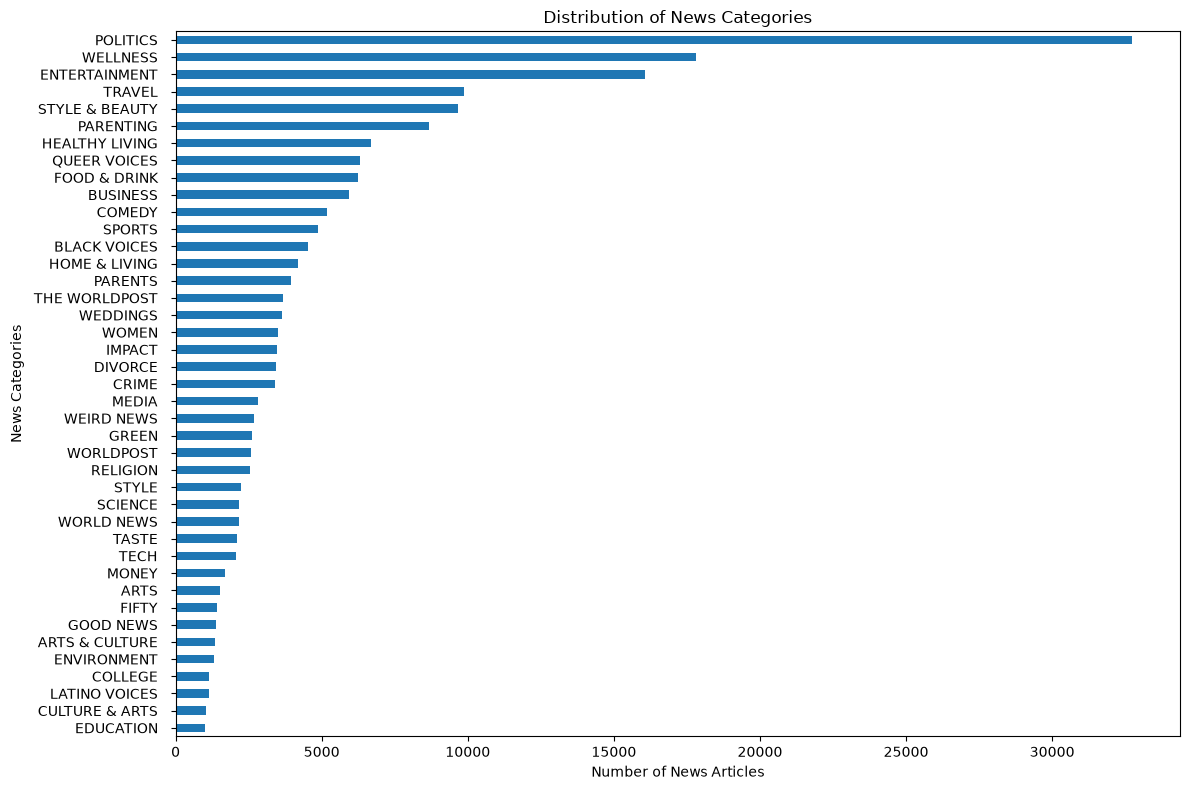

In [35]:
# Lets plot the graph n see the imbalance in the category column

import matplotlib.pyplot as plt
category_counts= df['category'].value_counts()

plt.figure(figsize=(12,8))

category_counts.sort_values().plot(kind='barh')
plt.title("Distribution of News Categories")
plt.xlabel("Number of News Articles")
plt.ylabel("News Categories")
plt.tight_layout()
plt.show()




In [36]:
# Now checking for duplicate values
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate headlines:", df["headline"].duplicated().sum())

Duplicate rows: 370
Duplicate headlines: 10999


In [37]:
# Check if the duplicate headlines have the same or different categories.



duplicated_headline= df[df['headline'].duplicated(keep=False)]
duplicated_headline[['headline', 'category']].sort_values(by='headline').head(20)





,headline,category
82270,authors,POLITICS
86893,authors,RELIGION
95001,authors,WORLDPOST
100426,authors,BUSINESS
101479,authors,MEDIA
113471,authors,QUEER VOICES
90114,#BlackLivesMatter,POLITICS
98107,#BlackLivesMatter,BLACK VOICES
94685,#ExceptionalCareers Series,BUSINESS
97786,#ExceptionalCareers Series,BUSINESS


In [38]:
# Checking how many repeated headlines have more than one category.
conflicting_headlines = duplicated_headline.groupby('headline')['category'].nunique()

print("Number of conflicting headlines:", conflicting_headlines[conflicting_headlines > 1].sum())

Number of conflicting headlines: 1961


In [39]:
# only remove the exact duplicate rows.
df=df.drop_duplicates()
print("Shape after removing duplicates:",df.shape)

Shape after removing duplicates: (200483, 4)


In [40]:
# Remove only conflicting headlines from the dataset.
conflicting_headline=duplicated_headline.groupby('headline')['category'].nunique()

conflicting_headline=conflicting_headline[conflicting_headline>1].index

df=df[~df['headline'].isin(conflicting_headline)]
print("Shape after removing conflicting headlines:",df.shape)

Shape after removing conflicting headlines: (195596, 4)


##### Insights : 370 exact duplicate rows → Removed.
##### 10,999 duplicate headlines → Not all removed; same-category duplicates were retained.
##### 1,961 conflicting headlines → Removed because the same headline had different categories.
##### Final dataset: 195,596 rows.

In [41]:
# Lets count Headline length
df['headline_word_count']=df['headline'].str.split().str.len()

df["headline_word_count"].describe()

count    195596.000000
mean          9.335666
std           3.798857
min           1.000000
25%           7.000000
50%          10.000000
75%          12.000000
max          45.000000
Name: headline_word_count, dtype: float64

#### Insight
-Headlines contain about 9 words on average.
-The median is 10 words, showing that most headlines are short.
-75% of headlines contain 12 words or fewer.
-The maximum length is 45 words, so a few headlines are much longer.
-This suggests that the dataset is suitable for RNN-based text classification, as most input sequences are relatively short.
-The word-count analysis will help us choose an appropriate sequence length for padding later.

#### Check for headline sentence and doing some basic text cleaning

In [ ]:

df['headline'].head(10)

0     There Were 2 Mass Shootings In Texas Last Wee...
1     Will Smith Joins Diplo And Nicky Jam For The ...
2     Hugh Grant Marries For The First Time At Age ...
3     Jim Carrey Blasts 'Castrato' Adam Schiff And ...
4     Julianna Margulies Uses Donald Trump Poop Bag...
5     Morgan Freeman 'Devastated' That Sexual Haras...
6     Donald Trump Is Lovin' New McDonald's Jingle ...
7     What To Watch On Amazon Prime That\u2019s New...
8     Mike Myers Reveals He'd 'Like To' Do A Fourth...
9     What To Watch On Hulu That\u2019s New This We...
Name: headline, dtype: str

In [45]:
# convert headlines to lowercase
df['headline'] = df['headline'].str.lower()
df['headline'].head(10)

0     there were 2 mass shootings in texas last wee...
1     will smith joins diplo and nicky jam for the ...
2     hugh grant marries for the first time at age ...
3     jim carrey blasts 'castrato' adam schiff and ...
4     julianna margulies uses donald trump poop bag...
5     morgan freeman 'devastated' that sexual haras...
6     donald trump is lovin' new mcdonald's jingle ...
7     what to watch on amazon prime that\u2019s new...
8     mike myers reveals he'd 'like to' do a fourth...
9     what to watch on hulu that\u2019s new this we...
Name: headline, dtype: str

In [47]:
df['headline']= df['headline'].str.replace(r"[^\w\s]", "",regex=True)

In [48]:
df["headline"].head(10)

0     there were 2 mass shootings in texas last wee...
1     will smith joins diplo and nicky jam for the ...
2     hugh grant marries for the first time at age ...
3     jim carrey blasts castrato adam schiff and de...
4     julianna margulies uses donald trump poop bag...
5     morgan freeman devastated that sexual harassm...
6     donald trump is lovin new mcdonalds jingle in...
7     what to watch on amazon prime thatu2019s new ...
8     mike myers reveals hed like to do a fourth au...
9     what to watch on hulu thatu2019s new this wee...
Name: headline, dtype: str

In [50]:
# Lets fix u2019s issue 
df['headline']=df['headline'].str.replace("u2019s","",regex=False)
df['headline'].head(10)

0     there were 2 mass shootings in texas last wee...
1     will smith joins diplo and nicky jam for the ...
2     hugh grant marries for the first time at age ...
3     jim carrey blasts castrato adam schiff and de...
4     julianna margulies uses donald trump poop bag...
5     morgan freeman devastated that sexual harassm...
6     donald trump is lovin new mcdonalds jingle in...
7     what to watch on amazon prime that new this w...
8     mike myers reveals hed like to do a fourth au...
9     what to watch on hulu that new this week authors
Name: headline, dtype: str

In [51]:
# Lets count the character length of the headline
df['headline_char_count']=df['headline'].str.len()
df['headline_char_count'].describe()

count    195596.000000
mean         58.158965
std          22.987946
min           1.000000
25%          42.000000
50%          61.000000
75%          75.000000
max         318.000000
Name: headline_char_count, dtype: float64

#### Insight: The cleaned headlines contain an average of approximately 58 characters, with a median of 61 characters. Most headlines are relatively short, although a few longer headlines extend up to 318 characters.

#### Insight: Average headline ≈ 9.3 words
#### Average headline ≈ 58 characters
#### Maximum ≈ 45 words / 318 characters